In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\prathap\Desktop\Customer Intelligence & Automated Reporting Platform\customer-intelligence-platform"
)

sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT.exists())

True


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.database import engine


In [3]:
query = """
SELECT *
FROM customer_churn_modeling
"""

churn_df = pd.read_sql(query, engine)

churn_df.head()

,customer_id,recency_days,frequency,monetary_value,average_order_value,unique_products,total_quantity,average_order_gap,customer_tenure_days,churned
0,12346,235,22,77804.96,3536.59,27,74285.0,22.16,400,1
1,12347,39,6,3402.39,567.07,107,2099.0,55.00,275,0
2,12348,158,4,1709.40,427.35,25,2497.0,63.33,190,0
3,12349,317,3,2671.14,890.38,90,993.0,91.00,182,0
4,12350,220,1,334.40,334.40,17,197.0,NaN,0,1


In [4]:
churn_df.shape

(5281, 10)

In [5]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5281 entries, 0 to 5280
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           5281 non-null   int64  
 1   recency_days          5281 non-null   int64  
 2   frequency             5281 non-null   int64  
 3   monetary_value        5281 non-null   float64
 4   average_order_value   5281 non-null   float64
 5   unique_products       5281 non-null   int64  
 6   total_quantity        5281 non-null   float64
 7   average_order_gap     3705 non-null   float64
 8   customer_tenure_days  5281 non-null   int64  
 9   churned               5281 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 412.7 KB


In [6]:
churn_df.isnull().sum()

customer_id                0
recency_days               0
frequency                  0
monetary_value             0
average_order_value        0
unique_products            0
total_quantity             0
average_order_gap       1576
customer_tenure_days       0
churned                    0
dtype: int64

In [7]:
churn_df["churned"].value_counts()

churned
1    2991
0    2290
Name: count, dtype: int64

In [8]:
churn_df["churned"].value_counts(normalize=True) * 100

churned
1    56.637001
0    43.362999
Name: proportion, dtype: float64

In [9]:
churn_df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,5281.0,15324.100170,1712.323865,12346.0,13850.00,15313.00,16807.00,18287.00
recency_days,5281.0,207.814240,175.029112,1.0,50.00,164.00,327.00,648.00
frequency,5281.0,7.621473,34.929925,1.0,1.00,3.00,7.00,2061.00
monetary_value,5281.0,3663.638292,25638.130359,2.9,323.25,824.92,2240.77,1109063.12
average_order_value,5281.0,363.926315,525.235850,2.9,171.92,272.30,405.40,13506.54
unique_products,5281.0,74.356751,104.968606,1.0,18.00,41.00,92.00,2182.00
total_quantity,5281.0,1621.389888,8047.616060,1.0,167.00,438.00,1198.00,298022.00
average_order_gap,3705.0,88.097484,82.028994,0.0,35.23,64.00,113.00,632.00
customer_tenure_days,5281.0,224.504261,218.975562,0.0,0.00,171.00,418.00,646.00
churned,5281.0,0.566370,0.495622,0.0,0.00,1.00,1.00,1.00


In [10]:
churn_df["customer_id"].duplicated().sum()

np.int64(0)

In [11]:
churn_df["churned"].unique()

array([1, 0])

In [12]:
feature_columns = [
    "recency_days",
    "frequency",
    "monetary_value",
    "average_order_value",
    "unique_products",
    "total_quantity",
    "average_order_gap",
    "customer_tenure_days"
]

X = churn_df[feature_columns].copy()
y = churn_df["churned"].copy()

X.shape, y.shape

((5281, 8), (5281,))

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training: (4224, 8)
Testing : (1057, 8)

Training target distribution:
churned
1    0.566288
0    0.433712
Name: proportion, dtype: float64

Testing target distribution:
churned
1    0.566698
0    0.433302
Name: proportion, dtype: float64


In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [15]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [16]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [17]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_logistic))

Accuracy : 0.7436140018921475
Precision: 0.7492401215805471
Recall   : 0.8230383973288815
F1 Score : 0.7844073190135242
ROC-AUC  : 0.7957330631110076


In [19]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.73      0.64      0.68       458
           1       0.75      0.82      0.78       599

    accuracy                           0.74      1057
   macro avg       0.74      0.73      0.73      1057
weighted avg       0.74      0.74      0.74      1057



In [20]:
confusion_matrix(y_test, y_pred_logistic)

array([[293, 165],
       [106, 493]])

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
random_forest_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [23]:
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [24]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [25]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.738883632923368
Precision: 0.7421289355322339
Recall   : 0.8263772954924875
F1 Score : 0.7819905213270142
ROC-AUC  : 0.7920041408169365


In [26]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.62      0.67       458
           1       0.74      0.83      0.78       599

    accuracy                           0.74      1057
   macro avg       0.74      0.73      0.73      1057
weighted avg       0.74      0.74      0.74      1057



In [27]:
confusion_matrix(y_test, y_pred_rf)

array([[286, 172],
       [104, 495]])

In [28]:
from xgboost import XGBClassifier

In [29]:
xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [30]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [31]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.738883632923368
Precision: 0.7378497790868925
Recall   : 0.8363939899833055
F1 Score : 0.784037558685446
ROC-AUC  : 0.7939688418105866


In [33]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.74      0.61      0.67       458
           1       0.74      0.84      0.78       599

    accuracy                           0.74      1057
   macro avg       0.74      0.72      0.73      1057
weighted avg       0.74      0.74      0.73      1057



In [34]:
confusion_matrix(y_test, y_pred_xgb)

array([[280, 178],
       [ 98, 501]])

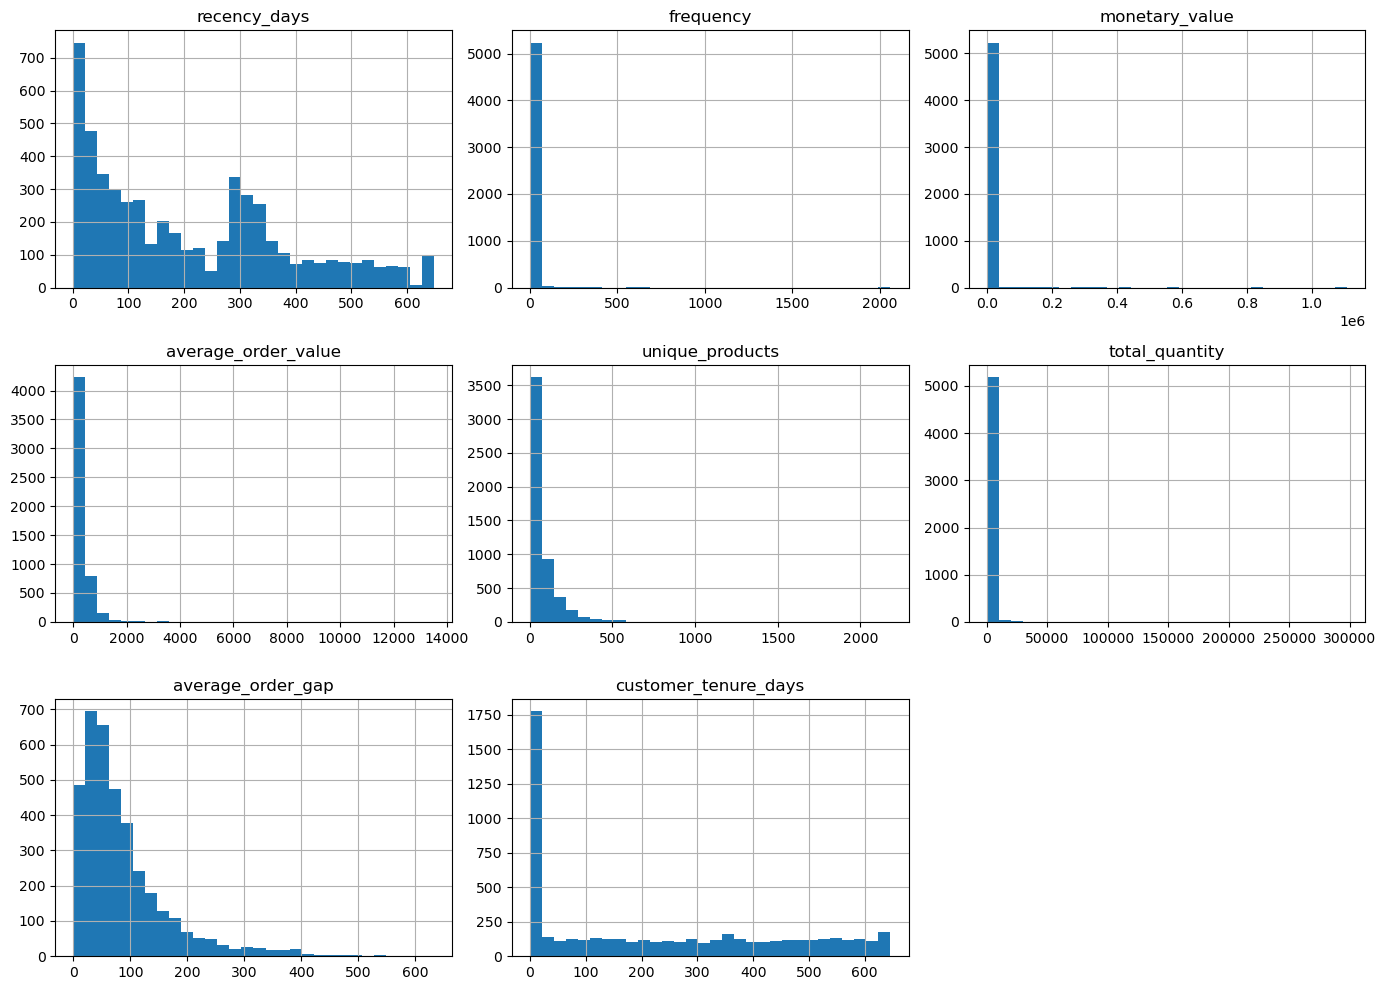

In [35]:
import matplotlib.pyplot as plt

numeric_features = [
    "recency_days",
    "frequency",
    "monetary_value",
    "average_order_value",
    "unique_products",
    "total_quantity",
    "average_order_gap",
    "customer_tenure_days"
]

churn_df[numeric_features].hist(
    bins=30,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

In [36]:
churn_df[numeric_features].skew().sort_values(ascending=False)

frequency               41.731798
monetary_value          27.568037
total_quantity          20.578178
average_order_value     13.457563
unique_products          6.120714
average_order_gap        2.154580
recency_days             0.665248
customer_tenure_days     0.456334
dtype: float64

In [37]:
log_features = [
    "frequency",
    "monetary_value",
    "average_order_value",
    "unique_products",
    "total_quantity",
    "average_order_gap"
]

normal_features = [
    "recency_days",
    "customer_tenure_days"
]

In [38]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [39]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [40]:
preprocessor_log = ColumnTransformer([
    ("log_features", log_pipeline, log_features),
    ("normal_features", normal_pipeline, normal_features)
])

In [41]:
logistic_log_pipeline = Pipeline([
    ("preprocessor", preprocessor_log),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [42]:
logistic_log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('log_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['frequency',
                                                   'monetary_value',
                                                   'average_order_value',
                                                   'unique_products',
                                                   'total_quantity',
                                                   'average_order_gap']),
                                                 ('normal_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['recency_days',
                                                   'customer_tenure_days'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [43]:
y_pred_log = logistic_log_pipeline.predict(X_test)

y_prob_log = logistic_log_pipeline.predict_proba(X_test)[:, 1]

In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log))

Accuracy : 0.7379375591296121
Precision: 0.7484567901234568
Recall   : 0.8096828046744574
F1 Score : 0.7778668805132317
ROC-AUC  : 0.7975592508620628


In [45]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.72      0.64      0.68       458
           1       0.75      0.81      0.78       599

    accuracy                           0.74      1057
   macro avg       0.73      0.73      0.73      1057
weighted avg       0.74      0.74      0.74      1057



In [46]:
confusion_matrix(y_test, y_pred_log)

array([[295, 163],
       [114, 485]])

In [47]:
y_train_prob_xgb = xgb_pipeline.predict_proba(X_train)[:, 1]

print(
    "XGBoost Train ROC-AUC:",
    roc_auc_score(y_train, y_train_prob_xgb)
)

print(
    "XGBoost Test ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb)
)

XGBoost Train ROC-AUC: 0.9042140103109346
XGBoost Test ROC-AUC: 0.7939688418105866


In [48]:
y_train_prob_logistic = logistic_pipeline.predict_proba(X_train)[:, 1]

print(
    "Logistic Train ROC-AUC:",
    roc_auc_score(y_train, y_train_prob_logistic)
)

print(
    "Logistic Test ROC-AUC:",
    roc_auc_score(y_test, y_prob_logistic)
)

Logistic Train ROC-AUC: 0.7941587496896496
Logistic Test ROC-AUC: 0.7957330631110076


In [49]:
xgb_configs = [
    {
        "n_estimators": 150,
        "max_depth": 2,
        "learning_rate": 0.05,
        "min_child_weight": 5
    },
    {
        "n_estimators": 200,
        "max_depth": 2,
        "learning_rate": 0.03,
        "min_child_weight": 5
    },
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 5
    },
    {
        "n_estimators": 150,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 10
    }
]

In [50]:
results = []

for i, config in enumerate(xgb_configs, start=1):

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            learning_rate=config["learning_rate"],
            min_child_weight=config["min_child_weight"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": f"XGB_{i}",
        "train_auc": roc_auc_score(y_train, train_prob),
        "test_auc": roc_auc_score(y_test, test_prob),
        "gap": (
            roc_auc_score(y_train, train_prob)
            - roc_auc_score(y_test, test_prob)
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "test_auc",
    ascending=False
)

,model,train_auc,test_auc,gap
2,XGB_3,0.833043,0.804835,0.028208
3,XGB_4,0.835286,0.803422,0.031864
1,XGB_2,0.819120,0.803156,0.015964
0,XGB_1,0.822014,0.801485,0.020529


In [51]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [52]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [53]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "auc": "roc_auc",
        "f1": "f1",
        "precision": "precision",
        "recall": "recall"
    },
    n_jobs=-1,
    return_train_score=True
)

print(
    "Logistic CV ROC-AUC:",
    logistic_cv["test_auc"].mean()
)

print(
    "Logistic CV ROC-AUC Std:",
    logistic_cv["test_auc"].std()
)

Logistic CV ROC-AUC: 0.7932426524472789
Logistic CV ROC-AUC Std: 0.015297853373558346


In [54]:
cv_results = []

for i, config in enumerate(xgb_configs, start=1):

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            learning_rate=config["learning_rate"],
            min_child_weight=config["min_child_weight"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "auc": "roc_auc",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall"
        },
        n_jobs=-1,
        return_train_score=True
    )

    cv_results.append({
        "model": f"XGB_{i}",
        "cv_auc_mean": cv_result["test_auc"].mean(),
        "cv_auc_std": cv_result["test_auc"].std(),
        "cv_f1_mean": cv_result["test_f1"].mean(),
        "cv_precision_mean": cv_result["test_precision"].mean(),
        "cv_recall_mean": cv_result["test_recall"].mean(),
        "train_auc_mean": cv_result["train_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    "cv_auc_mean",
    ascending=False
)

,model,cv_auc_mean,cv_auc_std,cv_f1_mean,cv_precision_mean,cv_recall_mean,train_auc_mean
1,XGB_2,0.803965,0.016383,0.777676,0.734873,0.826099,0.821342
2,XGB_3,0.803959,0.017193,0.777011,0.736178,0.822752,0.837900
0,XGB_1,0.803394,0.017015,0.778984,0.736782,0.826514,0.824120
3,XGB_4,0.802699,0.017429,0.777402,0.736549,0.823168,0.840592


In [55]:
xgb3_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [56]:
xgb3_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [57]:
y_pred_final = xgb3_pipeline.predict(X_test)

y_prob_final = xgb3_pipeline.predict_proba(X_test)[:, 1]

In [58]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final)
}

final_metrics

{'Accuracy': 0.7407757805108799,
 'Precision': 0.7372262773722628,
 'Recall': 0.8430717863105175,
 'F1': 0.7866043613707165,
 'ROC-AUC': np.float64(0.8048348411836321)}

In [59]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.75      0.61      0.67       458
           1       0.74      0.84      0.79       599

    accuracy                           0.74      1057
   macro avg       0.74      0.73      0.73      1057
weighted avg       0.74      0.74      0.74      1057



In [60]:
confusion_matrix(y_test, y_pred_final)

array([[278, 180],
       [ 94, 505]])

In [61]:
xgb_model = xgb3_pipeline.named_steps["model"]

In [62]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,recency_days,0.310563
1,frequency,0.161407
5,total_quantity,0.139857
6,average_order_gap,0.105398
2,monetary_value,0.095907
4,unique_products,0.073597
7,customer_tenure_days,0.072293
3,average_order_value,0.040979


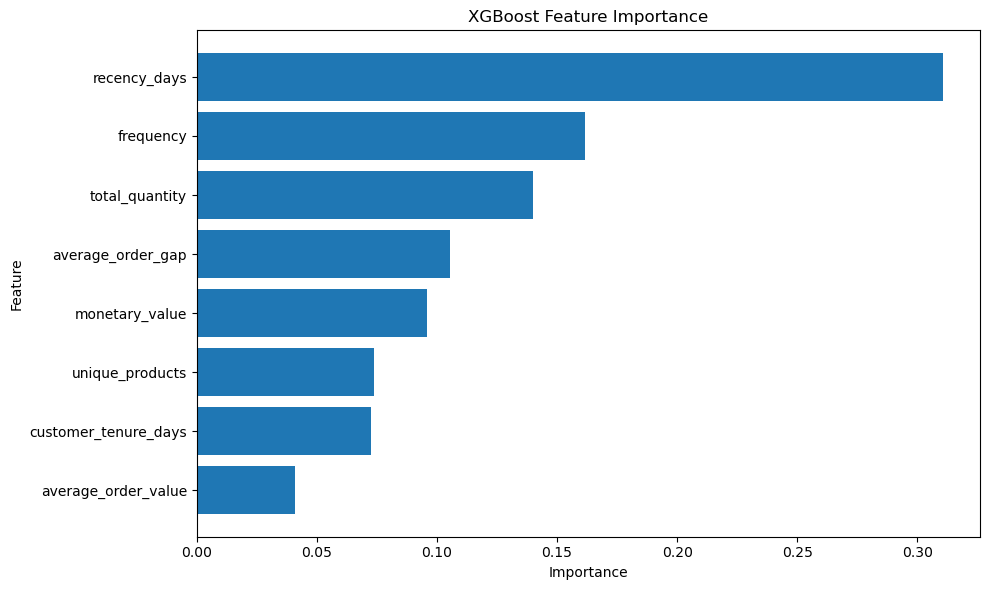

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [64]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [65]:
import shap
print("SHAP imported successfully")

SHAP imported successfully


In [66]:
explainer = shap.TreeExplainer(xgb_model)

In [67]:
imputer = xgb3_pipeline.named_steps["imputer"]

X_train_imputed = pd.DataFrame(
    imputer.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [68]:
shap_values = explainer(X_test_imputed)

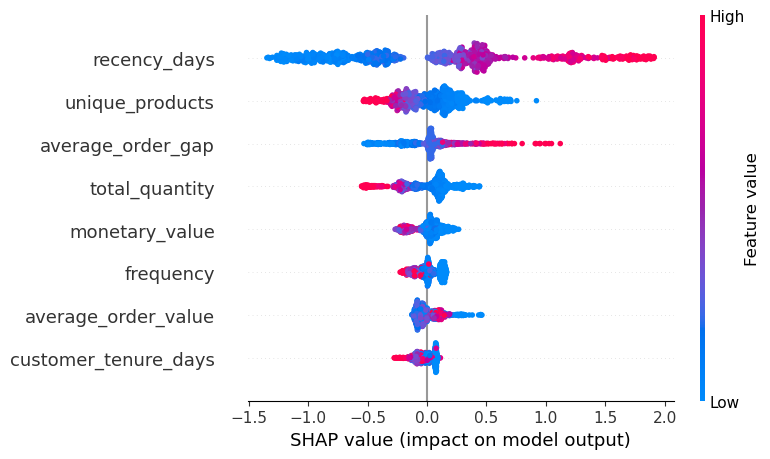

In [69]:
shap.summary_plot(
    shap_values,
    X_test_imputed
)

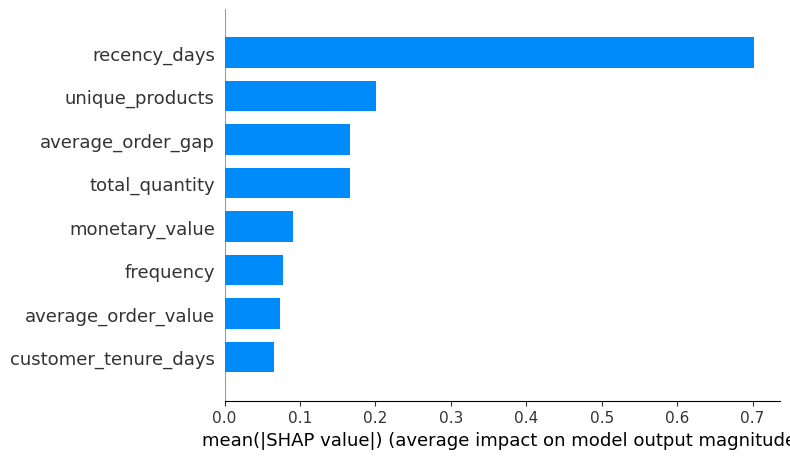

In [70]:
shap.summary_plot(
    shap_values,
    X_test_imputed,
    plot_type="bar"
)

In [71]:
xgb3_pipeline
X_train
X_test
y_train
y_test

2983    1
5192    1
2987    0
5027    1
1519    0
       ..
836     1
3423    0
4832    1
493     1
2973    1
Name: churned, Length: 1057, dtype: int64

In [72]:
# Pick one customer from the test set
customer_index = X_test.index[0]

customer_features = X_test.loc[[customer_index]]

customer_id = churn_df.loc[customer_index, "customer_id"]

print("Customer ID:", customer_id)
customer_features

Customer ID: 15710


,recency_days,frequency,monetary_value,average_order_value,unique_products,total_quantity,average_order_gap,customer_tenure_days
2983,327,1,898.87,898.87,110,641.0,NaN,0


In [73]:
churn_probability = xgb3_pipeline.predict_proba(customer_features)[0, 1]

prediction = xgb3_pipeline.predict(customer_features)[0]

print(f"Customer ID: {customer_id}")
print(f"Churn Probability: {churn_probability:.2%}")
print(f"Predicted Class: {prediction}")

Customer ID: 15710
Churn Probability: 70.40%
Predicted Class: 1


In [74]:
# Extract the trained XGBoost model
xgb_model = xgb3_pipeline.named_steps["model"]

# Extract the imputer
imputer = xgb3_pipeline.named_steps["imputer"]

# Apply the same preprocessing used during training
customer_imputed = pd.DataFrame(
    imputer.transform(customer_features),
    columns=customer_features.columns,
    index=customer_features.index
)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
customer_shap = explainer(customer_imputed)

print(customer_shap)

.values =
array([[ 0.49038392,  0.13623668,  0.03211172,  0.10162202, -0.21718478,
        -0.00766685,  0.01792366,  0.04508564]], dtype=float32)

.base_values =
array([0.26783177], dtype=float32)

.data =
array([[327.  ,   1.  , 898.87, 898.87, 110.  , 641.  ,  63.  ,   0.  ]])


In [75]:
shap_values_customer = customer_shap.values[0]

explanation = pd.DataFrame({
    "feature": customer_imputed.columns,
    "feature_value": customer_imputed.iloc[0].values,
    "shap_value": shap_values_customer
})

explanation["impact"] = explanation["shap_value"].apply(
    lambda x: "Increases churn risk" if x > 0 else "Decreases churn risk"
)

explanation = explanation.sort_values(
    "shap_value",
    key=lambda x: x.abs(),
    ascending=False
)

explanation

,feature,feature_value,shap_value,impact
0,recency_days,327.00,0.490384,Increases churn risk
4,unique_products,110.00,-0.217185,Decreases churn risk
1,frequency,1.00,0.136237,Increases churn risk
3,average_order_value,898.87,0.101622,Increases churn risk
7,customer_tenure_days,0.00,0.045086,Increases churn risk
2,monetary_value,898.87,0.032112,Increases churn risk
6,average_order_gap,63.00,0.017924,Increases churn risk
5,total_quantity,641.00,-0.007667,Decreases churn risk


In [76]:
top_drivers = explanation.head(5)

print("Top churn drivers:")
print()

for _, row in top_drivers.iterrows():
    direction = "↑ Churn Risk" if row["shap_value"] > 0 else "↓ Churn Risk"
    
    print(
        f"{row['feature']:<25} "
        f"{row['shap_value']:+.3f}  "
        f"{direction}"
    )

Top churn drivers:

recency_days              +0.490  ↑ Churn Risk
unique_products           -0.217  ↓ Churn Risk
frequency                 +0.136  ↑ Churn Risk
average_order_value       +0.102  ↑ Churn Risk
customer_tenure_days      +0.045  ↑ Churn Risk


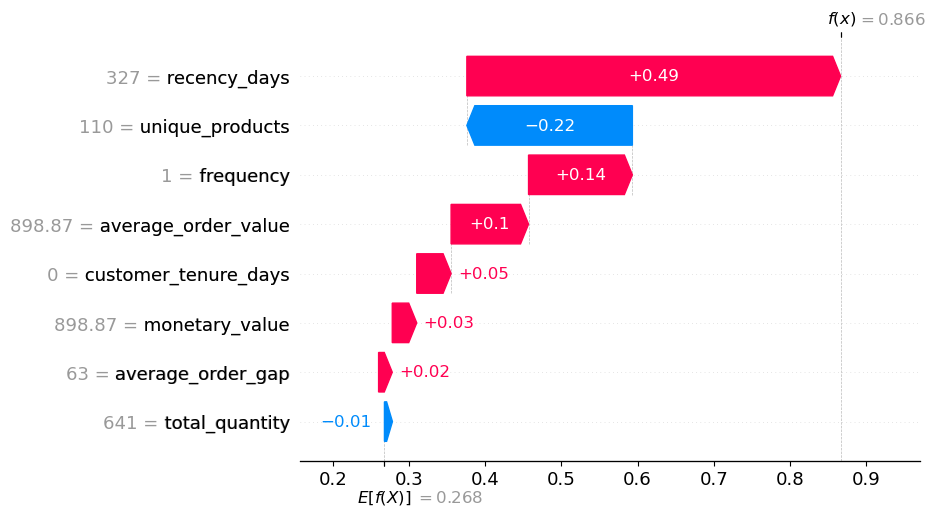

In [77]:
shap.plots.waterfall(customer_shap[0], max_display=8)

In [78]:
if churn_probability >= 0.75:
    risk_level = "HIGH"
elif churn_probability >= 0.50:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

print(f"Customer ID: {customer_id}")
print(f"Churn Probability: {churn_probability:.2%}")
print(f"Risk Level: {risk_level}")

Customer ID: 15710
Churn Probability: 70.40%
Risk Level: MEDIUM


In [79]:
if risk_level == "HIGH":
    recommendation = (
        "Prioritize this customer for a retention/reactivation campaign."
    )
elif risk_level == "MEDIUM":
    recommendation = (
        "Monitor this customer and consider a targeted engagement campaign."
    )
else:
    recommendation = (
        "Continue regular engagement; no immediate retention intervention required."
    )

print("Recommended Action:")
print(recommendation)

Recommended Action:
Monitor this customer and consider a targeted engagement campaign.


In [80]:
churn_drivers = explanation[
    explanation["shap_value"] > 0
].head(3)

protective_factors = explanation[
    explanation["shap_value"] < 0
].head(3)

print("TOP CHURN DRIVERS")
print("=================")

for _, row in churn_drivers.iterrows():
    print(
        f"{row['feature']}: "
        f"{row['shap_value']:+.3f}"
    )

print("\nPROTECTIVE FACTORS")
print("==================")

for _, row in protective_factors.iterrows():
    print(
        f"{row['feature']}: "
        f"{row['shap_value']:+.3f}"
    )

TOP CHURN DRIVERS
recency_days: +0.490
frequency: +0.136
average_order_value: +0.102

PROTECTIVE FACTORS
unique_products: -0.217
total_quantity: -0.008


In [81]:
print(f"Customer ID: {customer_id}")
print(f"Churn Probability: {churn_probability:.2%}")
print(f"Risk Level: {risk_level}")

explanation

Customer ID: 15710
Churn Probability: 70.40%
Risk Level: MEDIUM


,feature,feature_value,shap_value,impact
0,recency_days,327.00,0.490384,Increases churn risk
4,unique_products,110.00,-0.217185,Decreases churn risk
1,frequency,1.00,0.136237,Increases churn risk
3,average_order_value,898.87,0.101622,Increases churn risk
7,customer_tenure_days,0.00,0.045086,Increases churn risk
2,monetary_value,898.87,0.032112,Increases churn risk
6,average_order_gap,63.00,0.017924,Increases churn risk
5,total_quantity,641.00,-0.007667,Decreases churn risk


In [82]:
# Get top 3 churn drivers
top_churn_drivers = (
    explanation[explanation["shap_value"] > 0]
    .sort_values("shap_value", ascending=False)
    .head(3)
)

print(f"Customer {customer_id} - Business Explanation")
print("=" * 50)

print(f"Churn Probability: {churn_probability:.2%}")
print(f"Risk Level: {risk_level}")

print("\nTop Churn Drivers:")

for _, row in top_churn_drivers.iterrows():
    print(
        f"- {row['feature']}: "
        f"value={row['feature_value']}, "
        f"SHAP={row['shap_value']:+.3f}"
    )

Customer 15710 - Business Explanation
Churn Probability: 70.40%
Risk Level: MEDIUM

Top Churn Drivers:
- recency_days: value=327.0, SHAP=+0.490
- frequency: value=1.0, SHAP=+0.136
- average_order_value: value=898.87, SHAP=+0.102


In [83]:
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
Path("../models").mkdir(parents=True, exist_ok=True)

# Save the complete pipeline
model_path = "../models/churn_xgb_pipeline.joblib"

joblib.dump(xgb3_pipeline, model_path)

print(f"Model saved successfully: {model_path}")

Model saved successfully: ../models/churn_xgb_pipeline.joblib


In [84]:
loaded_model = joblib.load(model_path)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [85]:
loaded_probability = loaded_model.predict_proba(customer_features)[0, 1]
loaded_prediction = loaded_model.predict(customer_features)[0]

print(f"Original probability : {churn_probability:.6f}")
print(f"Loaded probability   : {loaded_probability:.6f}")
print(f"Original prediction  : {prediction}")
print(f"Loaded prediction    : {loaded_prediction}")

Original probability : 0.703984
Loaded probability   : 0.703984
Original prediction  : 1
Loaded prediction    : 1


In [86]:
from pathlib import Path

model_file = Path("../models/churn_xgb_pipeline.joblib")

print("Exists:", model_file.exists())
print("Size:", round(model_file.stat().st_size / 1024, 2), "KB")

Exists: True
Size: 226.1 KB


In [87]:
shap_explainer = shap.TreeExplainer(
    xgb3_pipeline.named_steps["model"]
)

joblib.dump(
    shap_explainer,
    "../models/shap_explainer.joblib"
)

print("SHAP explainer saved successfully.")

SHAP explainer saved successfully.


In [88]:
print(type(loaded_model))
print(f"Original probability : {churn_probability:.6f}")
print(f"Loaded probability   : {loaded_probability:.6f}")
print(f"Original prediction  : {prediction}")
print(f"Loaded prediction    : {loaded_prediction}")

<class 'sklearn.pipeline.Pipeline'>
Original probability : 0.703984
Loaded probability   : 0.703984
Original prediction  : 1
Loaded prediction    : 1
